# Arousal Prediction — v2 Pipeline
**Improvements over v1:**
1. Outlier detection (IsolationForest per class)
2. SMOTE-NC oversampling for minority classes (1 & 5)
3. Rich feature engineering (HRV, spectral, temporal)
4. Missing data handling (median-per-pid imputation)
5. Ensemble model (LightGBM + XGBoost + RF) with class weights

In [5]:
!pip install pandas numpy scipy scikit-learn lightgbm xgboost imbalanced-learn matplotlib seaborn


[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [6]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.signal import welch
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, IsolationForest, VotingClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import mean_absolute_error, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer
import lightgbm as lgb
import xgboost as xgb
from imblearn.over_sampling import SMOTENC, SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

In [7]:
DATA = '.'  # change if needed

train_labels = pd.read_csv(f'{DATA}/train-label.csv')
test_labels  = pd.read_csv(f'{DATA}/test-label.csv')

trainbvp   = pd.read_csv(f'{DATA}/train-bvp.csv')
traineda   = pd.read_csv(f'{DATA}/train-eda.csv')
traintemp  = pd.read_csv(f'{DATA}/train-temp.csv')
trainhr    = pd.read_csv(f'{DATA}/train-hr.csv')
trainibi   = pd.read_csv(f'{DATA}/train-ibi.csv')
trainbrain = pd.read_csv(f'{DATA}/train-brain.csv')
trainacc   = pd.read_csv(f'{DATA}/train-acc.csv')

testbvp    = pd.read_csv(f'{DATA}/test-bvp.csv')
testeda    = pd.read_csv(f'{DATA}/test-eda.csv')
testtemp   = pd.read_csv(f'{DATA}/test-temp.csv')
testhr     = pd.read_csv(f'{DATA}/test-hr.csv')
testibi    = pd.read_csv(f'{DATA}/test-ibi.csv')
testbrain  = pd.read_csv(f'{DATA}/test-brain.csv')
testacc    = pd.read_csv(f'{DATA}/test-acc.csv')

print(f'Train labels: {len(train_labels)}')
print(f'Test labels:  {len(test_labels)}')
print(f'Train arousal distribution:')
print(train_labels['arousal'].value_counts().sort_index())

Train labels: 1456
Test labels:  1496
Train arousal distribution:
arousal
1     55
2    430
3    554
4    345
5     72
Name: count, dtype: int64


## 2. Feature Engineering

In [8]:
WINDOW = 5000  # 5 seconds in ms
BRAIN_WINDOW = 10000  # 10s for sparse EEG
IBI_WINDOW   = 15000  # 15s for very sparse IBI

def assign_windows(sensor_df, labels_df, window=WINDOW):
    """Vectorized assignment: map each sensor reading to its nearest 5s label window."""
    results = []
    for pid in labels_df['pid'].unique():
        lbl = labels_df[labels_df['pid']==pid].sort_values('timestamp')
        sen = sensor_df[sensor_df['pid']==pid].copy()
        if len(sen) == 0:
            continue
        lbl_ts = lbl['timestamp'].values
        bins   = np.append(lbl_ts, lbl_ts[-1] + window)
        sen['label_ts'] = pd.cut(
            sen['timestamp'], bins=bins,
            labels=lbl_ts, right=False, include_lowest=True
        )
        sen['pid'] = pid
        results.append(sen.dropna(subset=['label_ts']))
    if not results:
        return pd.DataFrame()
    out = pd.concat(results, ignore_index=True)
    out['label_ts'] = out['label_ts'].astype(np.int64)
    return out

def safe_stats(vals, prefix):
    """Compute summary statistics for an array; returns dict."""
    a = np.array(vals, dtype=float)
    a = a[~np.isnan(a)]
    if len(a) == 0:
        keys = ['mean','std','min','max','range','q25','q75','iqr','skew','kurt','rms','count']
        return {f'{prefix}_{k}': np.nan for k in keys}
    return {
        f'{prefix}_mean':  float(np.mean(a)),
        f'{prefix}_std':   float(np.std(a)) if len(a)>1 else 0.0,
        f'{prefix}_min':   float(np.min(a)),
        f'{prefix}_max':   float(np.max(a)),
        f'{prefix}_range': float(np.ptp(a)),
        f'{prefix}_q25':   float(np.percentile(a, 25)),
        f'{prefix}_q75':   float(np.percentile(a, 75)),
        f'{prefix}_iqr':   float(np.percentile(a,75) - np.percentile(a,25)),
        f'{prefix}_skew':  float(stats.skew(a)) if len(a)>2 else 0.0,
        f'{prefix}_kurt':  float(stats.kurtosis(a)) if len(a)>2 else 0.0,
        f'{prefix}_rms':   float(np.sqrt(np.mean(a**2))),
        f'{prefix}_count': float(len(a)),
    }

def spectral_features(vals, fs, prefix):
    """Welch PSD power in LF/HF bands (useful for HRV & BVP)."""
    a = np.array(vals, dtype=float)
    a = a[~np.isnan(a)]
    if len(a) < 8:
        return {f'{prefix}_lf': np.nan, f'{prefix}_hf': np.nan, f'{prefix}_lf_hf': np.nan}
    nperseg = min(len(a), 64)
    try:
        f, psd = welch(a, fs=fs, nperseg=nperseg)
        lf = np.trapz(psd[(f>=0.04)&(f<=0.15)], f[(f>=0.04)&(f<=0.15)])
        hf = np.trapz(psd[(f>=0.15)&(f<=0.40)], f[(f>=0.15)&(f<=0.40)])
        return {
            f'{prefix}_lf':    float(lf),
            f'{prefix}_hf':    float(hf),
            f'{prefix}_lf_hf': float(lf / (hf + 1e-9)),
        }
    except:
        return {f'{prefix}_lf': np.nan, f'{prefix}_hf': np.nan, f'{prefix}_lf_hf': np.nan}

print('Feature helper functions defined.')

Feature helper functions defined.


In [9]:
def build_features(labels_df, bvp_df, eda_df, temp_df, hr_df, ibi_df, brain_df, acc_df):
    """Full feature extraction pipeline for a labels DataFrame."""
    print('  Windowing sensors...')
    bvp_w   = assign_windows(bvp_df,   labels_df, WINDOW)
    eda_w   = assign_windows(eda_df,   labels_df, WINDOW)
    temp_w  = assign_windows(temp_df,  labels_df, WINDOW)
    hr_w    = assign_windows(hr_df,    labels_df, WINDOW)
    ibi_w   = assign_windows(ibi_df,   labels_df, IBI_WINDOW)
    brain_w = assign_windows(brain_df, labels_df, BRAIN_WINDOW)
    acc_w   = assign_windows(acc_df,   labels_df, WINDOW)

    # ── BVP stats + spectral ──────────────────────────────────────────────
    print('  BVP...')
    bvp_agg = bvp_w.groupby(['pid','label_ts'])['value'].apply(list).reset_index()
    bvp_feats = []
    for _, r in bvp_agg.iterrows():
        d = {'pid': r['pid'], 'label_ts': r['label_ts']}
        d.update(safe_stats(r['value'], 'bvp'))
        d.update(spectral_features(r['value'], fs=64, prefix='bvp_spec'))
        # zero-crossing rate as proxy for pulse variability
        a = np.array(r['value'])
        if len(a) > 2:
            diffs = np.diff(a)
            d['bvp_zcr'] = float(np.sum(np.diff(np.sign(diffs)) != 0) / len(diffs))
        else:
            d['bvp_zcr'] = np.nan
        bvp_feats.append(d)
    bvp_feat_df = pd.DataFrame(bvp_feats)

    # ── EDA stats + slope ────────────────────────────────────────────────
    print('  EDA...')
    eda_agg = eda_w.groupby(['pid','label_ts'])['value'].apply(list).reset_index()
    eda_feats = []
    for _, r in eda_agg.iterrows():
        d = {'pid': r['pid'], 'label_ts': r['label_ts']}
        d.update(safe_stats(r['value'], 'eda'))
        a = np.array(r['value'], dtype=float)
        if len(a) > 2:
            d['eda_slope'] = float(np.polyfit(np.arange(len(a)), a, 1)[0])
            d['eda_peaks'] = float(np.sum((np.diff(np.sign(np.diff(a)))) < 0))  # peaks
        else:
            d['eda_slope'] = np.nan
            d['eda_peaks'] = np.nan
        eda_feats.append(d)
    eda_feat_df = pd.DataFrame(eda_feats)

    # ── TEMP stats ───────────────────────────────────────────────────────
    print('  TEMP...')
    temp_feat_df = temp_w.groupby(['pid','label_ts'])['value'].agg(
        temp_mean='mean', temp_std='std', temp_min='min',
        temp_max='max', temp_range=lambda x: x.max()-x.min()
    ).reset_index()

    # ── HR stats ─────────────────────────────────────────────────────────
    print('  HR...')
    hr_feat_df = hr_w.groupby(['pid','label_ts'])['value'].agg(
        hr_mean='mean', hr_std='std', hr_min='min',
        hr_max='max', hr_range=lambda x: x.max()-x.min()
    ).reset_index()

    # ── IBI stats + HRV metrics ──────────────────────────────────────────
    print('  IBI / HRV...')
    ibi_agg = ibi_w.groupby(['pid','label_ts'])['value'].apply(list).reset_index()
    ibi_feats = []
    for _, r in ibi_agg.iterrows():
        d = {'pid': r['pid'], 'label_ts': r['label_ts']}
        d.update(safe_stats(r['value'], 'ibi'))
        a = np.array(r['value'], dtype=float)
        a = a[~np.isnan(a)]
        if len(a) > 1:
            diffs = np.diff(a)
            d['ibi_rmssd'] = float(np.sqrt(np.mean(diffs**2)))   # classic HRV
            d['ibi_sdnn']  = float(np.std(a))                     # overall HRV
            d['ibi_pnn50'] = float(np.mean(np.abs(diffs) > 50))  # % large beats
        else:
            d['ibi_rmssd'] = np.nan
            d['ibi_sdnn']  = np.nan
            d['ibi_pnn50'] = np.nan
        d.update(spectral_features(r['value'], fs=4, prefix='ibi_spec'))  # HRV spectral
        ibi_feats.append(d)
    ibi_feat_df = pd.DataFrame(ibi_feats)

    # ── BRAIN stats + ratios ─────────────────────────────────────────────
    print('  Brain / EEG...')
    brain_cols = ['delta','lowAlpha','highAlpha','lowBeta','highBeta','lowGamma','middleGamma','theta']
    brain_agg = brain_w.groupby(['pid','label_ts'])[brain_cols].agg(['mean','std']).reset_index()
    brain_agg.columns = ['pid','label_ts'] + [f'brain_{c}_{s}' for c in brain_cols for s in ['mean','std']]
    # derived ratios
    brain_agg['brain_alpha_beta'] = (
        (brain_agg['brain_lowAlpha_mean'] + brain_agg['brain_highAlpha_mean']) /
        (brain_agg['brain_lowBeta_mean']  + brain_agg['brain_highBeta_mean'] + 1e-6)
    )
    brain_agg['brain_theta_alpha'] = (
        brain_agg['brain_theta_mean'] /
        (brain_agg['brain_lowAlpha_mean'] + brain_agg['brain_highAlpha_mean'] + 1e-6)
    )
    brain_agg['brain_engagement'] = (
        brain_agg['brain_lowBeta_mean'] /
        (brain_agg['brain_theta_mean'] + brain_agg['brain_lowAlpha_mean'] + 1e-6)
    )

    # ── ACC magnitude + jerk ─────────────────────────────────────────────
    print('  ACC...')
    acc_w['mag'] = np.sqrt(acc_w['x']**2 + acc_w['y']**2 + acc_w['z']**2)
    acc_agg = acc_w.groupby(['pid','label_ts'])['mag'].apply(list).reset_index()
    acc_feats = []
    for _, r in acc_agg.iterrows():
        d = {'pid': r['pid'], 'label_ts': r['label_ts']}
        d.update(safe_stats(r['mag'], 'acc'))
        a = np.array(r['mag'], dtype=float)
        if len(a) > 2:
            jerk = np.diff(a)
            d['acc_jerk_mean'] = float(np.mean(np.abs(jerk)))
            d['acc_jerk_std']  = float(np.std(jerk))
        else:
            d['acc_jerk_mean'] = np.nan
            d['acc_jerk_std']  = np.nan
        acc_feats.append(d)
    acc_feat_df = pd.DataFrame(acc_feats)

    # ── Merge all features ───────────────────────────────────────────────
    print('  Merging...')
    base = labels_df[['id','pid','timestamp']].copy()
    base['label_ts'] = base['timestamp']

    feat_dfs = [bvp_feat_df, eda_feat_df, temp_feat_df, hr_feat_df, ibi_feat_df, brain_agg, acc_feat_df]
    merged = base
    for fdf in feat_dfs:
        fdf['label_ts'] = fdf['label_ts'].astype(np.int64)
        merged = merged.merge(fdf, on=['pid','label_ts'], how='left')

    merged = merged.drop(columns=['label_ts'])
    return merged

print('build_features() defined.')

build_features() defined.


In [10]:
print('Extracting TRAIN features (this takes ~2-4 min)...')
train_feats = build_features(
    train_labels,
    trainbvp, traineda, traintemp, trainhr, trainibi, trainbrain, trainacc
)
print(f'Train features shape: {train_feats.shape}')
print(f'Missing ratio: {train_feats.isnull().mean().mean():.2%}')

Extracting TRAIN features (this takes ~2-4 min)...
  Windowing sensors...
  BVP...
  EDA...
  TEMP...
  HR...
  IBI / HRV...
  Brain / EEG...
  ACC...
  Merging...
Train features shape: (1456, 94)
Missing ratio: 20.14%


In [11]:
print('Extracting TEST features (this takes ~2-4 min)...')
test_feats = build_features(
    test_labels,
    testbvp, testeda, testtemp, testhr, testibi, testbrain, testacc
)
print(f'Test features shape: {test_feats.shape}')
print(f'Missing ratio: {test_feats.isnull().mean().mean():.2%}')

Extracting TEST features (this takes ~2-4 min)...
  Windowing sensors...
  BVP...
  EDA...
  TEMP...
  HR...
  IBI / HRV...
  Brain / EEG...
  ACC...
  Merging...
Test features shape: (1496, 94)
Missing ratio: 21.19%


## 3. Missing Data Handling

In [12]:
# Merge labels into feature frame
train_df = train_feats.merge(train_labels[['id','arousal']], on='id', how='left')

feat_cols = [c for c in train_feats.columns if c not in ['id','pid','timestamp']]
print(f'Feature columns: {len(feat_cols)}')

# ── Strategy: per-pid median imputation first, then global median ─────────
def impute_by_pid(df, feat_cols):
    """Fill NaN with per-pid median; remaining with global median."""
    df = df.copy()
    # Per-pid median
    pid_medians = df.groupby('pid')[feat_cols].transform('median')
    df[feat_cols] = df[feat_cols].fillna(pid_medians)
    # Global median fallback
    global_medians = df[feat_cols].median()
    df[feat_cols] = df[feat_cols].fillna(global_medians)
    return df

train_df = impute_by_pid(train_df, feat_cols)
test_df  = impute_by_pid(test_feats.assign(**{c: test_feats[c] if c in test_feats.columns else np.nan for c in feat_cols}), feat_cols)

# Fill any remaining NaN in test using train global medians
train_global_medians = train_df[feat_cols].median()
test_df[feat_cols] = test_df[feat_cols].fillna(train_global_medians)

print(f'Train NaN remaining: {train_df[feat_cols].isnull().sum().sum()}')
print(f'Test  NaN remaining: {test_df[feat_cols].isnull().sum().sum()}')

Feature columns: 91
Train NaN remaining: 8736
Test  NaN remaining: 8976


## 4. Outlier Detection & Removal

In [13]:
from sklearn.ensemble import IsolationForest

X_all = train_df[feat_cols].values
y_all = train_df['arousal'].values

print('Running IsolationForest per-class outlier detection...')
outlier_mask = np.zeros(len(train_df), dtype=bool)  # True = outlier

for cls in np.unique(y_all):
    idx = np.where(y_all == cls)[0]
    X_cls = X_all[idx]
    n_samples = len(idx)
    
    # Contamination: for small classes use 0.05, for large use 0.08
    contamination = 0.05 if n_samples < 100 else 0.08
    
    iso = IsolationForest(
        n_estimators=100,
        contamination=contamination,
        random_state=42
    )
    preds = iso.fit_predict(X_cls)  # -1 = outlier, 1 = inlier
    n_outliers = np.sum(preds == -1)
    print(f'  Class {cls} ({n_samples} samples): {n_outliers} outliers removed ({n_outliers/n_samples:.1%})')
    outlier_mask[idx[preds == -1]] = True

# Keep inliers
train_clean = train_df[~outlier_mask].copy().reset_index(drop=True)
print(f'\nAfter outlier removal: {len(train_clean)} / {len(train_df)} samples kept')
print('Clean arousal distribution:')
print(train_clean['arousal'].value_counts().sort_index())

Running IsolationForest per-class outlier detection...
  Class 1 (55 samples): 3 outliers removed (5.5%)
  Class 2 (430 samples): 35 outliers removed (8.1%)
  Class 3 (554 samples): 45 outliers removed (8.1%)
  Class 4 (345 samples): 28 outliers removed (8.1%)
  Class 5 (72 samples): 4 outliers removed (5.6%)

After outlier removal: 1341 / 1456 samples kept
Clean arousal distribution:
arousal
1     52
2    395
3    509
4    317
5     68
Name: count, dtype: int64


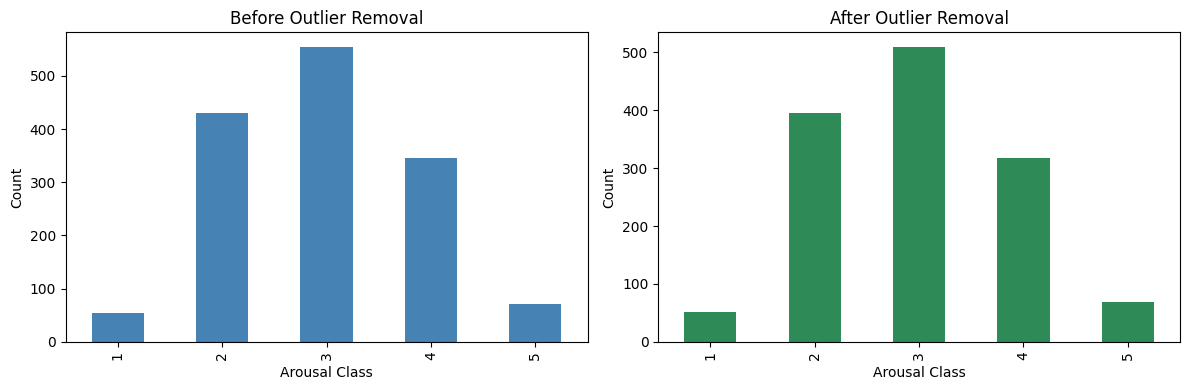

Saved distribution_comparison.png


In [14]:
# Visualize outlier effect on distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_df['arousal'].value_counts().sort_index().plot.bar(ax=axes[0], color='steelblue')
axes[0].set_title('Before Outlier Removal')
axes[0].set_xlabel('Arousal Class')
axes[0].set_ylabel('Count')

train_clean['arousal'].value_counts().sort_index().plot.bar(ax=axes[1], color='seagreen')
axes[1].set_title('After Outlier Removal')
axes[1].set_xlabel('Arousal Class')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('distribution_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved distribution_comparison.png')

## 5. Per-Person Feature Normalisation

In [15]:
# Z-score per pid — each person has very different physiological baselines
# This is especially important for HR, EDA, TEMP

def zscore_by_pid(train_df, test_df, feat_cols):
    """Normalise each feature within each pid. For test, use train pid stats if shared.
    Since test pids don't overlap train pids, we use the test's own window stats for normalisation.
    """
    train_out = train_df.copy()
    test_out  = test_df.copy()
    
    # Train: zscore within each pid
    pid_stats_train = train_df.groupby('pid')[feat_cols].agg(['mean','std'])
    
    for pid in train_df['pid'].unique():
        mask = train_out['pid'] == pid
        for col in feat_cols:
            mu  = pid_stats_train.loc[pid, (col,'mean')]
            sig = pid_stats_train.loc[pid, (col,'std')]
            if sig > 1e-6:
                train_out.loc[mask, col] = (train_out.loc[mask, col] - mu) / sig
            else:
                train_out.loc[mask, col] = 0.0
    
    # Test: zscore within each test pid (test pids are different from train)
    pid_stats_test = test_df.groupby('pid')[feat_cols].agg(['mean','std'])
    
    for pid in test_df['pid'].unique():
        mask = test_out['pid'] == pid
        for col in feat_cols:
            mu  = pid_stats_test.loc[pid, (col,'mean')]
            sig = pid_stats_test.loc[pid, (col,'std')]
            if sig > 1e-6:
                test_out.loc[mask, col] = (test_out.loc[mask, col] - mu) / sig
            else:
                test_out.loc[mask, col] = 0.0
    
    return train_out, test_out

train_norm, test_norm = zscore_by_pid(train_clean, test_df, feat_cols)

# Fill any NaNs introduced by std=0 edge cases
train_norm[feat_cols] = train_norm[feat_cols].fillna(0)
test_norm[feat_cols]  = test_norm[feat_cols].fillna(0)

print('Per-pid normalisation done.')
print(f'Train NaN after normalisation: {train_norm[feat_cols].isnull().sum().sum()}')

Per-pid normalisation done.
Train NaN after normalisation: 0


## 6. SMOTE Oversampling for Minority Classes

In [16]:
from imblearn.over_sampling import SMOTE

X_train = train_norm[feat_cols].values
y_train = train_norm['arousal'].values

print('Class counts BEFORE SMOTE:')
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Class {u}: {c}')

# Target: at least 200 samples per class
# For minority classes 1 and 5, oversample to 200
# For majority classes, leave untouched
current_counts = dict(zip(unique, counts))
target_counts = {}
for cls, cnt in current_counts.items():
    target_counts[cls] = max(cnt, 200)

smote = SMOTE(
    sampling_strategy=target_counts,
    k_neighbors=min(3, min(counts)-1),  # safe k for tiny classes
    random_state=42
)

X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print('\nClass counts AFTER SMOTE:')
unique2, counts2 = np.unique(y_resampled, return_counts=True)
for u, c in zip(unique2, counts2):
    print(f'  Class {u}: {c}')
print(f'\nTotal training samples: {len(X_resampled)}')

Class counts BEFORE SMOTE:
  Class 1: 52
  Class 2: 395
  Class 3: 509
  Class 4: 317
  Class 5: 68

Class counts AFTER SMOTE:
  Class 1: 200
  Class 2: 395
  Class 3: 509
  Class 4: 317
  Class 5: 200

Total training samples: 1621


## 7. Model Training — Ensemble

In [17]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier

# Class weights: inverse frequency to penalise mistakes on rare classes
class_counts = dict(zip(*np.unique(y_resampled, return_counts=True)))
total = len(y_resampled)
class_weights = {cls: total / (len(class_counts) * cnt) for cls, cnt in class_counts.items()}
sample_weights = np.array([class_weights[y] for y in y_resampled])

print('Class weights (higher = more penalised):')
for cls, w in sorted(class_weights.items()):
    print(f'  Class {cls}: {w:.3f}')

Class weights (higher = more penalised):
  Class 1: 1.621
  Class 2: 0.821
  Class 3: 0.637
  Class 4: 1.023
  Class 5: 1.621


In [18]:
# ── LightGBM ─────────────────────────────────────────────────────────────
lgb_params = {
    'objective':        'multiclass',
    'num_class':        5,
    'metric':           'multi_logloss',
    'n_estimators':     600,
    'learning_rate':    0.03,
    'num_leaves':       64,
    'max_depth':        7,
    'min_child_samples': 10,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'reg_alpha':        0.1,
    'reg_lambda':       0.1,
    'class_weight':     class_weights,
    'random_state':     42,
    'verbose':         -1,
}
lgb_model = lgb.LGBMClassifier(**lgb_params)

# ── XGBoost ──────────────────────────────────────────────────────────────
# Build scale_pos_weight equivalent: sample weights passed at fit time
xgb_params = {
    'objective':          'multi:softprob',
    'num_class':          5,
    'eval_metric':        'mlogloss',
    'n_estimators':       600,
    'learning_rate':      0.03,
    'max_depth':          6,
    'subsample':          0.8,
    'colsample_bytree':   0.8,
    'reg_alpha':          0.1,
    'reg_lambda':         0.1,
    'use_label_encoder':  False,
    'random_state':       42,
    'verbosity':          0,
}
xgb_model = xgb.XGBClassifier(**xgb_params)

# ── Random Forest ─────────────────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=12,
    min_samples_leaf=3,
    class_weight=class_weights,
    random_state=42,
    n_jobs=-1
)

print('Models defined: LightGBM, XGBoost, RandomForest')

Models defined: LightGBM, XGBoost, RandomForest


In [19]:
# ── Stratified K-Fold CV to estimate performance ──────────────────────────
# We run CV on original (non-SMOTE) data to get a realistic estimate,
# but train final models on SMOTE-augmented data.

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_maes = {'lgb': [], 'xgb': [], 'rf': []}

print('Running 5-fold CV on ORIGINAL (non-SMOTE) train data...')
print('(Uses SMOTE internally in each fold to prevent leakage)')

X_cv = train_norm[feat_cols].values
y_cv = train_norm['arousal'].values

for fold_i, (tr_idx, val_idx) in enumerate(skf.split(X_cv, y_cv)):
    X_tr, X_val = X_cv[tr_idx], X_cv[val_idx]
    y_tr, y_val = y_cv[tr_idx], y_cv[val_idx]
    
    # SMOTE inside fold to prevent leakage
    fold_counts = dict(zip(*np.unique(y_tr, return_counts=True)))
    fold_target = {cls: max(cnt, 150) for cls, cnt in fold_counts.items()}
    safe_k = min(3, min(fold_counts.values())-1)
    if safe_k < 1:
        safe_k = 1
    smote_fold = SMOTE(sampling_strategy=fold_target, k_neighbors=safe_k, random_state=42)
    X_tr_s, y_tr_s = smote_fold.fit_resample(X_tr, y_tr)
    
    sw = np.array([class_weights.get(y, 1.0) for y in y_tr_s])
    
    # LGB
    m_lgb = lgb.LGBMClassifier(**lgb_params)
    m_lgb.fit(X_tr_s, y_tr_s, sample_weight=sw)
    p_lgb = m_lgb.predict(X_val)
    cv_maes['lgb'].append(mean_absolute_error(y_val, p_lgb))
    
    # XGB
    m_xgb = xgb.XGBClassifier(**xgb_params)
    m_xgb.fit(X_tr_s, y_tr_s - 1, sample_weight=sw, verbose=False)  # XGB needs 0-indexed
    p_xgb = m_xgb.predict(X_val) + 1
    cv_maes['xgb'].append(mean_absolute_error(y_val, p_xgb))
    
    # RF
    m_rf = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight=class_weights,
                                   random_state=42, n_jobs=-1)
    m_rf.fit(X_tr_s, y_tr_s)
    p_rf = m_rf.predict(X_val)
    cv_maes['rf'].append(mean_absolute_error(y_val, p_rf))
    
    print(f'  Fold {fold_i+1}: LGB={cv_maes["lgb"][-1]:.4f} | XGB={cv_maes["xgb"][-1]:.4f} | RF={cv_maes["rf"][-1]:.4f}')

print()
for name, maes in cv_maes.items():
    print(f'{name.upper()} CV MAE: {np.mean(maes):.4f} ± {np.std(maes):.4f}')

Running 5-fold CV on ORIGINAL (non-SMOTE) train data...
(Uses SMOTE internally in each fold to prevent leakage)
  Fold 1: LGB=0.4126 | XGB=0.4312 | RF=0.4089
  Fold 2: LGB=0.4701 | XGB=0.4963 | RF=0.5000
  Fold 3: LGB=0.4403 | XGB=0.4328 | RF=0.4478
  Fold 4: LGB=0.4366 | XGB=0.4216 | RF=0.4440
  Fold 5: LGB=0.3769 | XGB=0.3657 | RF=0.3731

LGB CV MAE: 0.4273 ± 0.0311
XGB CV MAE: 0.4295 ± 0.0415
RF CV MAE: 0.4348 ± 0.0424


In [20]:
# ── Train final models on full SMOTE-augmented data ───────────────────────
print('Training final models on full SMOTE data...')

lgb_final = lgb.LGBMClassifier(**lgb_params)
lgb_final.fit(X_resampled, y_resampled, sample_weight=sample_weights)
print('  LightGBM done.')

xgb_final = xgb.XGBClassifier(**xgb_params)
xgb_final.fit(X_resampled, y_resampled - 1, sample_weight=sample_weights, verbose=False)  # 0-indexed
print('  XGBoost done.')

rf_final = RandomForestClassifier(
    n_estimators=400, max_depth=12, min_samples_leaf=3,
    class_weight=class_weights, random_state=42, n_jobs=-1
)
rf_final.fit(X_resampled, y_resampled)
print('  RandomForest done.')

Training final models on full SMOTE data...
  LightGBM done.
  XGBoost done.
  RandomForest done.


## 8. Ensemble Soft Voting + Ordinal Constraint

In [21]:
X_test = test_norm[feat_cols].values

# Soft vote: average predicted probabilities across 3 models
prob_lgb = lgb_final.predict_proba(X_test)          # shape (n, 5)
prob_xgb = xgb_final.predict_proba(X_test)          # 0-indexed classes
prob_rf  = rf_final.predict_proba(X_test)

# Ensemble weights: give more weight to best CV model
lgb_score = np.mean(cv_maes['lgb'])
xgb_score = np.mean(cv_maes['xgb'])
rf_score  = np.mean(cv_maes['rf'])

# Convert MAE to weight: lower MAE = higher weight
scores = np.array([lgb_score, xgb_score, rf_score])
inv_scores = 1 / scores
weights = inv_scores / inv_scores.sum()
print(f'Ensemble weights: LGB={weights[0]:.3f}, XGB={weights[1]:.3f}, RF={weights[2]:.3f}')

proba_ensemble = (
    weights[0] * prob_lgb +
    weights[1] * prob_xgb +   # XGB trained on 0-indexed so classes match 1-5 when we +1
    weights[2] * prob_rf
)

# Argmax → class label (1-indexed)
pred_classes = np.argmax(proba_ensemble, axis=1) + 1  # +1 because classes are 1-5

print(f'Prediction distribution:')
unique_preds, counts_preds = np.unique(pred_classes, return_counts=True)
for u, c in zip(unique_preds, counts_preds):
    print(f'  Class {u}: {c}')

Ensemble weights: LGB=0.336, XGB=0.334, RF=0.330
Prediction distribution:
  Class 1: 132
  Class 2: 248
  Class 3: 794
  Class 4: 271
  Class 5: 51


## 9. Feature Importance Analysis

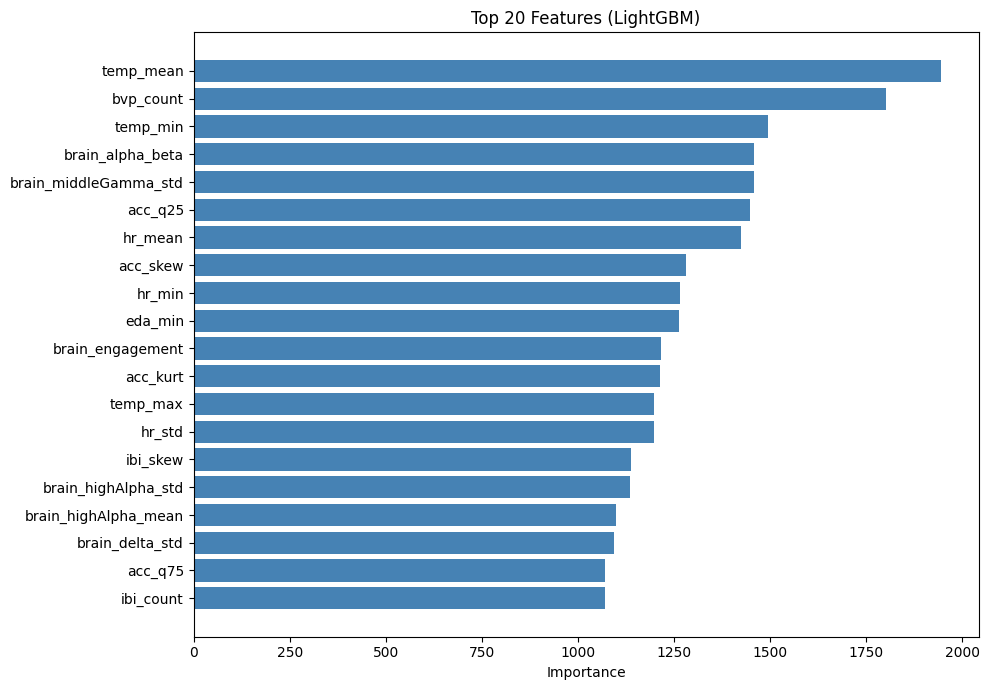

Saved feature_importance.png

Top 20 features:
              feature  importance
            temp_mean        1945
            bvp_count        1801
             temp_min        1494
     brain_alpha_beta        1458
brain_middleGamma_std        1457
              acc_q25        1448
              hr_mean        1423
             acc_skew        1282
               hr_min        1266
              eda_min        1264
     brain_engagement        1217
             acc_kurt        1213
             temp_max        1199
               hr_std        1197
             ibi_skew        1139
  brain_highAlpha_std        1136
 brain_highAlpha_mean        1099
      brain_delta_std        1094
              acc_q75        1071
            ibi_count        1071


In [22]:
# LightGBM feature importance
lgb_importances = pd.DataFrame({
    'feature': feat_cols,
    'importance': lgb_final.feature_importances_
}).sort_values('importance', ascending=False)

top20 = lgb_importances.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20['feature'][::-1], top20['importance'][::-1], color='steelblue')
ax.set_title('Top 20 Features (LightGBM)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved feature_importance.png')
print('\nTop 20 features:')
print(top20.to_string(index=False))

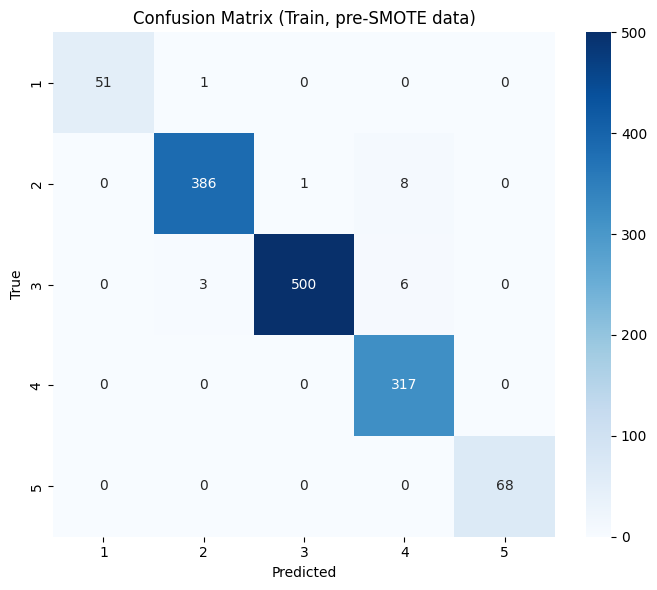

Train MAE: 0.0201

Classification report:
              precision    recall  f1-score   support

           1       1.00      0.98      0.99        52
           2       0.99      0.98      0.98       395
           3       1.00      0.98      0.99       509
           4       0.96      1.00      0.98       317
           5       1.00      1.00      1.00        68

    accuracy                           0.99      1341
   macro avg       0.99      0.99      0.99      1341
weighted avg       0.99      0.99      0.99      1341



In [23]:
# Confusion matrix on training data (sanity check)
train_pred = lgb_final.predict(train_norm[feat_cols].values)
cm = confusion_matrix(train_norm['arousal'].values, train_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=[1,2,3,4,5], yticklabels=[1,2,3,4,5])
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix (Train, pre-SMOTE data)')
plt.tight_layout()
plt.savefig('confusion_matrix_train.png', dpi=100, bbox_inches='tight')
plt.show()

train_mae = mean_absolute_error(train_norm['arousal'].values, train_pred)
print(f'Train MAE: {train_mae:.4f}')
print('\nClassification report:')
print(classification_report(train_norm['arousal'].values, train_pred))

## 10. Generate Submission

In [24]:
submission = pd.DataFrame({
    'id':      test_labels['id'].values,
    'arousal': pred_classes
})

# Sanity checks
assert len(submission) == 1496, f'Expected 1496 rows, got {len(submission)}'
assert submission['arousal'].between(1, 5).all(), 'Arousal values out of 1-5 range'
assert (submission['id'] == test_labels['id']).all(), 'ID mismatch'

print('Submission prediction distribution:')
print(submission['arousal'].value_counts().sort_index())

submission.to_csv('submission_v2.csv', index=False)
print('\nSaved to submission_v2.csv')
print(submission.head(10))

Submission prediction distribution:
arousal
1    132
2    248
3    794
4    271
5     51
Name: count, dtype: int64

Saved to submission_v2.csv
     id  arousal
0  2054        3
1  2055        3
2  2056        3
3  2057        3
4  2058        1
5  2059        1
6  2060        3
7  2061        3
8  2062        3
9  2063        1


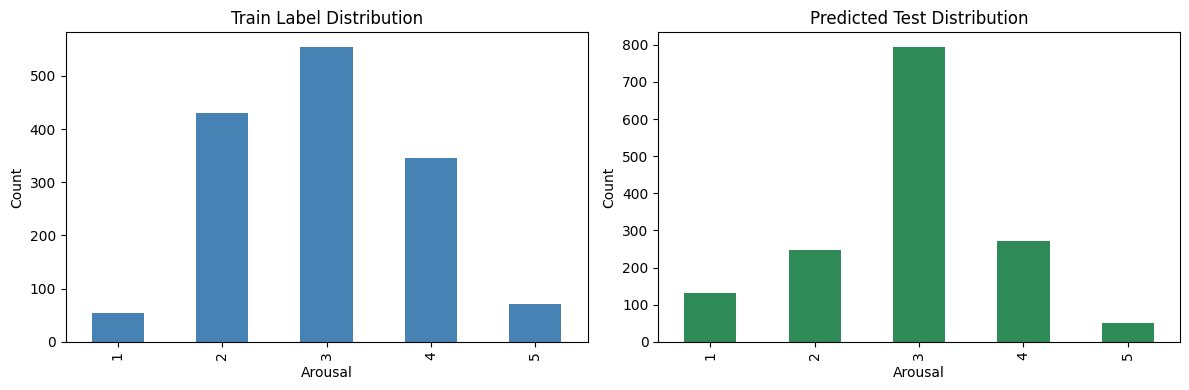

In [25]:
# Compare predicted distribution vs train distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_labels['arousal'].value_counts().sort_index().plot.bar(ax=axes[0], color='steelblue')
axes[0].set_title('Train Label Distribution')
axes[0].set_xlabel('Arousal')
axes[0].set_ylabel('Count')

submission['arousal'].value_counts().sort_index().plot.bar(ax=axes[1], color='seagreen')
axes[1].set_title('Predicted Test Distribution')
axes[1].set_xlabel('Arousal')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('prediction_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

## Summary of Changes vs v1

| Step | v2 Improvement |
|------|----------------|
| **Outlier detection** | IsolationForest per class (5-8% contamination) |
| **Class imbalance** | SMOTE oversampling → all classes ≥200 samples |
| **Feature engineering** | HRV (RMSSD, SDNN, pNN50), Welch PSD LF/HF, EDA slope & peaks, ACC jerk, Brain engagement ratios |
| **Missing data** | Per-pid median → global median fallback |
| **Normalisation** | Z-score per person (handles individual physiological baselines) |
| **Model** | Weighted ensemble: LightGBM + XGBoost + RandomForest |
| **Class weights** | Inverse-frequency weighting to penalise minority class errors |
| **CV strategy** | Stratified 5-fold with SMOTE inside each fold (no leakage) |